# Analysis of the Allegheny County Jail Oversight Board Meeting Minutes

- Contributor: Samiha Islam
- AI Acknowledgements: Copilot was used for debugging

## Topic Modeling Analysis

This notebook contains code that performs Topic Modeling Analysis, using BERT, of pre-processed JOB meeting minutes text. 

### Import libraries and lemmatized text data:
If transformers and BERTopic is not already imported, use !pip install transformers and !pip install bertopic

In [19]:
from transformers import AutoTokenizer, AutoModel
import torch
from pathlib import Path
import pickle
import numpy as np
from bertopic import BERTopic

# Load BERT Tokenizer and Model

In [8]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
embedding_model = AutoModel.from_pretrained('bert-base-uncased')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Load Documents from Preprocessing

In [3]:
BASE = Path("..").resolve()
OUT_DIR = BASE / "Data" / "Text"
path = OUT_DIR / "lemmatized_text.xz"

with open(path, 'rb') as f:
    documents = pickle.load(f)

In [ ]:
#BERT needs strings, not tokens, so we need to join the tokens back into strings
#BERT is supposed to be trained on normal English sentences, not the lemmatized tokens
#there may be some information lost here since we are not using the originat text, so we may want to test this on the original if there is time
documents = [' '.join(doc) if isinstance(doc, list) else str(doc) for doc in documents]


In [ ]:
# import os
# print(os.getcwd())
# print(OUT_DIR)

c:\Users\samih\UDA local\UDA project\board_meeting_analysis\Code
C:\Users\samih\UDA local\UDA project\board_meeting_analysis\Data\Text


# Tokenize text and make embedding vectors
This is heavily adapted from the Friday 4/24 recitation demo


In [ ]:
def embed_text(text):
    # Tokenize the input text
    token_ids = tokenizer.encode(
        text,
        truncation=True,
        max_length=512,
        return_tensors='pt'
    )
    
    # Run through BERT
    with torch.no_grad():
        outputs = embedding_model(token_ids)

    # Extract CLS embedding
    cls_embedding = outputs.last_hidden_state[:, 0, :]

    return cls_embedding.squeeze().numpy()

# Embed Vectors and View Topics Using BERTopic Default Paramaters



In [17]:
embeddings = [embed_text(doc) for doc in documents]
embeddings = np.vstack(embeddings)

In [43]:
#using default parameters for BERTopic, which uses UMAP for dimensionality reduction and HDBSCAN for clustering
#the recitation demo used custom umap and hdbscan paramaters
# we may want to experiment with making custom parameters (ie, making our own umap and hdbscan models) if the default parameters do not give good results

topic_model = BERTopic()
topics, probs = topic_model.fit_transform(documents, embeddings)
topic_model.get_topic_info()


,Topic,Count,Name,Representation,Representative_Docs
0,0,105,0_jail_judge_warden_board,"[jail, judge, warden, board, clark, county, in...",[1 monthly meeting allegheny county jail overs...
1,1,51,1_ms_hallam_judge_jail,"[ms, hallam, judge, jail, know, like, mr, okay...",[1 allegheny county jail oversight board meeti...


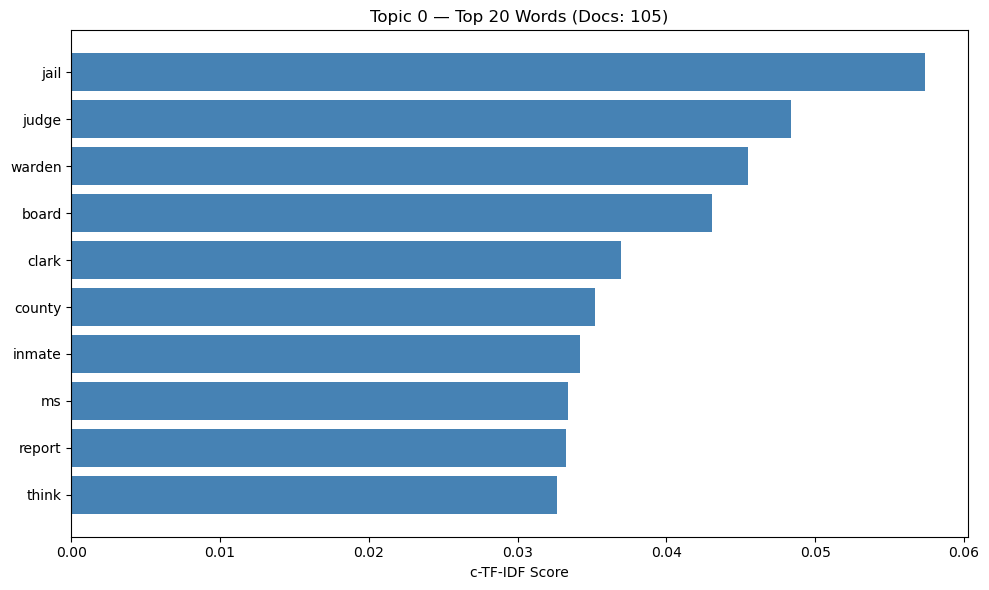

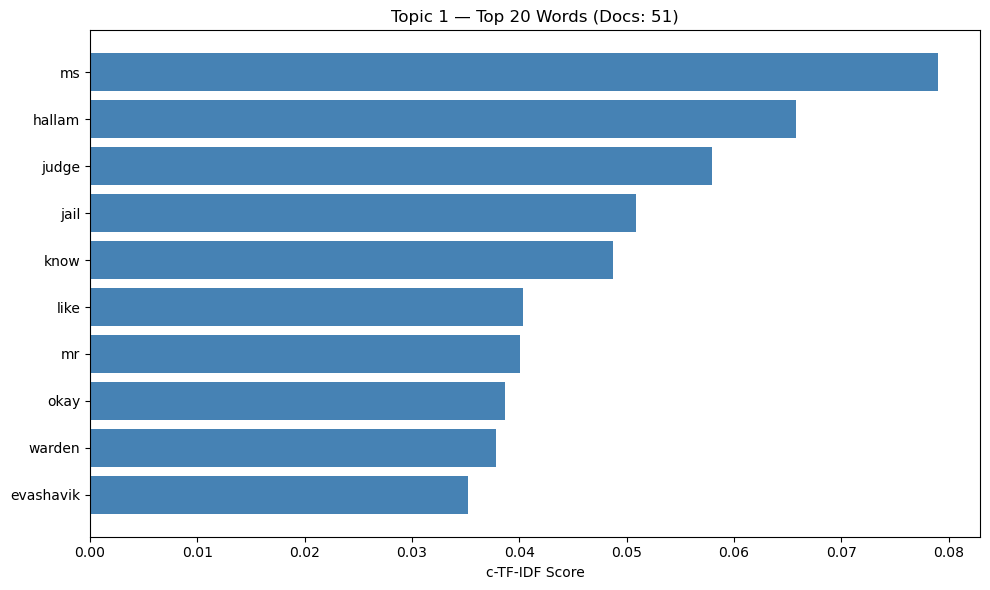

In [45]:
#see all words in eaach topic
import matplotlib.pyplot as plt

def plot_topic_words(topic_id, top_n=20):
    # Get topic info
    topic_info = topic_model.get_topic_info()
    count = topic_info.loc[topic_info['Topic'] == topic_id, 'Count'].values[0]

    # Get words
    words = topic_model.get_topic(topic_id)
    if words is None:
        print(f"Topic {topic_id} is empty")
        return
    
    words = words[:top_n]
    labels = [w[0] for w in words]
    scores = [w[1] for w in words]

  
    plt.figure(figsize=(10, 6))  

    plt.barh(labels, scores, color='steelblue')
    plt.gca().invert_yaxis()

    plt.title(f"Topic {topic_id} — Top {top_n} Words (Docs: {count})")
    plt.xlabel("c-TF-IDF Score")

    plt.tight_layout()             
    plt.show()
for topic_id in topic_model.get_topic_info().Topic:
    if topic_id == -1:
        continue
    plot_topic_words(topic_id, top_n=20)



The two topics created are incoherent. We should filter out names and words like board, judge, ms, jail and warden

# View Main Topics Across Years
We want to see what the main topics of discussion are under each warden's tenure 
* Tenure 1: Orlando Harper, September 2012 through September 2023
* Tenure 2: Shane Dady, October 2023 through December 2024
* Tenure 3: Trevor Wingard, January 2025 to present


Make a dataframe that stores the year and month for each document

In [ ]:
import re

def extract_year_month(text):
    # month names
    months = {
        "january": 1, "february": 2, "march": 3, "april": 4,
        "may": 5, "june": 6, "july": 7, "august": 8,
        "september": 9, "october": 10, "november": 11, "december": 12
    }
    
    # find year
    year_match = re.search(r"\b(20\d{2})\b", text)
    year = int(year_match.group(1)) if year_match else None
    
    # find month name
    month_match = re.search(r"(january|february|march|april|may|june|july|august|september|october|november|december)", text.lower())
    month = months[month_match.group(1)] if month_match else None
    
    return year, month


In [50]:
year_month = [extract_year_month(doc) for doc in documents]
years = [ym[0] for ym in year_month]
months = [ym[1] for ym in year_month]


In [ ]:
import pandas as pd
df = pd.DataFrame({
    "document": documents,
    "topic": topics,
    "year": years,
    "month": months
})

Define dates for each warden's tenure

In [53]:
tenure_1 = (
    (df["year"] > 2012) & (df["year"] < 2023)
) | (
    (df["year"] == 2012) & (df["month"] >= 9)
) | (
    (df["year"] == 2023) & (df["month"] <= 9)
)

tenure_2 = (
    (df["year"] == 2023) & (df["month"] >= 10)
) | (
    (df["year"] == 2024)
)

tenure_3 = df["year"] >= 2025

Assign each document to a tenure

In [65]:
df["period"] = None
df.loc[tenure_1, "period"] = "Harper"
df.loc[tenure_2, "period"] = "Dady"
df.loc[tenure_3, "period"] = "Wingard"

In [66]:
df["period"].value_counts()

period
Harper     118
Dady        17
Wingard     15
Name: count, dtype: int64

Show Topic Distributions by Tenure Time Period

In [67]:
topic_by_period = df.groupby(["period", "topic"]).size().unstack(fill_value=0)
topic_by_period

topic,0,1
period,,
Dady,0,17
Harper,99,19
Wingard,0,15


# The majority of documents are in Harper's tenure, as he was in office for over 10 years and the others were in office for less than 2 years. Calculating the percentage of documents in each topic for each period might give a better sense of the distribution

In [ ]:

topic_by_period_percent = topic_by_period.div(topic_by_period.sum(axis=1), axis=0) * 100

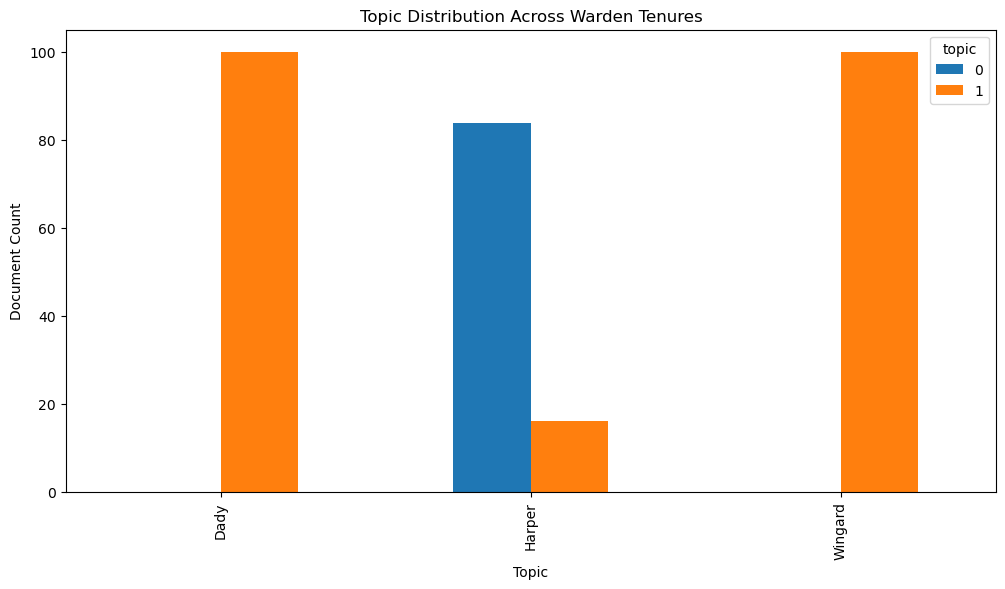

In [71]:
topic_by_period_percent.plot(kind="bar", figsize=(12,6))
plt.title("Topic Distribution Across Warden Tenures")
plt.xlabel("Topic")
plt.ylabel("Document Count")
plt.show()